In [11]:
import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *
from syn_project.utils_notebook import *

import os
import sys
import numpy as np

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_train import *
from syn_project.utils_color_analysis import *

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

%matplotlib widget
%matplotlib widget

In [ ]:
condition = "debug_color"
checkpoint_epoch = 0
n_samples_test = 10

# truth attr et n_iterations = 0: traduction attr vers image
# truth v_latents et n_iterations = 0: demi cycle v_latents
# truth v_latents, n_iterations = 1, p_truth = 0: cycle v_latents par attribut
truth = "color"
proportion_truth = 0.0
split = "train"
n_iterations = 1
noise_params = {'std': 0.0, 'mean': 0.0}


In [13]:
illusion = "v_latents"
if truth == "v_latents":
    illusion = "color"

experiment_name = get_experiment_name(condition, "biased_00", 0)
global_workspace = get_global_workspace("syn", experiment_name, epoch=checkpoint_epoch, nb_module=3)
data_module = get_data_module("syn",  experiment_name, nb_module=3)

test_samples = get_data_samples(data_module, n_samples_test, split=split)
unimodal_latents = global_workspace.encode_domains(test_samples)
gw_latents = global_workspace.encode(unimodal_latents)[frozenset({'color', 'v_latents'})]
latent_truth = gw_latents[truth]
latent_fusion = latent_truth

# à partir de l'input de la modalité truth, je traduis dans la modalité illusion, puis je fusionne l'encodage de l'input truth original et de illusion traduit.
# à partir de la fusion obtenue, je traduis en illusion, puis je fusionne l'encodage de l'input truth original et de la fusion précédente.
with torch.no_grad():
    for i in range(n_iterations):
        traduction = global_workspace.decode({truth: latent_fusion})
        unimodal_illusion = traduction[truth][illusion]

        sample = {frozenset({'color', 'v_latents'}): {illusion: unimodal_illusion}}
        l = global_workspace.encode_domains(sample)
        
        latent_illusion = global_workspace.encode(l)[frozenset({'color','v_latents'})][illusion].detach()
        
        latent_fusion = ((1 - proportion_truth) * latent_illusion + proportion_truth * latent_truth).detach()

        print(f"Iteration {i}: fusion mean = {latent_fusion.mean().item()}")

image_finale = global_workspace.decode({'fusion': latent_fusion})['fusion']['v_latents']
visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods['v_latents'])
image_finale_rgb = visual_module.decode_images(image_finale)

torch.cuda.empty_cache()

FileNotFoundError: Aucun fichier pickle trouvé dans /home/lucas/gwsyn/checkpoints/syn/debug_color_8_biased_00

In [ ]:
color_finale = global_workspace.decode({'fusion': latent_fusion})['fusion']['color']

In [ ]:
test_samples[frozenset({'color', 'v_latents'})]['color']

tensor([[0.8118, 0.7255, 0.9216],
        [0.2471, 0.1961, 0.5020],
        [0.1059, 0.4902, 0.1804],
        [0.8078, 0.6745, 0.7059],
        [0.2392, 0.3137, 0.2039],
        [0.7843, 0.6314, 0.0078],
        [0.6588, 0.6510, 0.5882],
        [0.9412, 0.7412, 0.6588],
        [0.6118, 0.8000, 0.6510],
        [0.1176, 0.0431, 0.5922]], device='cuda:0')

In [ ]:
color_finale

tensor([[ 1.5526,  1.8223,  3.1499],
        [ 0.2867,  0.3616,  0.6630],
        [-0.1350,  1.1098,  0.0711],
        [ 1.3213,  1.5133,  2.4681],
        [ 0.3873,  0.5144,  0.2396],
        [ 0.8803,  1.0962,  0.5318],
        [ 0.7618,  1.8909,  1.4948],
        [ 1.7022,  1.3031,  2.7078],
        [ 0.6821,  2.4855,  1.7943],
        [ 0.1693,  0.0329,  1.0874]], device='cuda:0',
       grad_fn=<AddmmBackward0>)

In [ ]:
visual_module = cast(VisualLatentDomainModule, global_workspace.domain_mods["v_latents"])

#decoded_images_rgb = visual_module.decode_images(decoded_image)
original_images = test_samples[frozenset({'color', 'v_latents'})]['v_latents']
original_images_rgb = visual_module.decode_images(original_images)
cat = test_samples[frozenset({'color', 'v_latents'})]['color']
colors_np = get_samples_rgb({"train_images": None, "images_decoded": image_finale_rgb}, 'decoded_edge')

import matplotlib.pyplot as plt



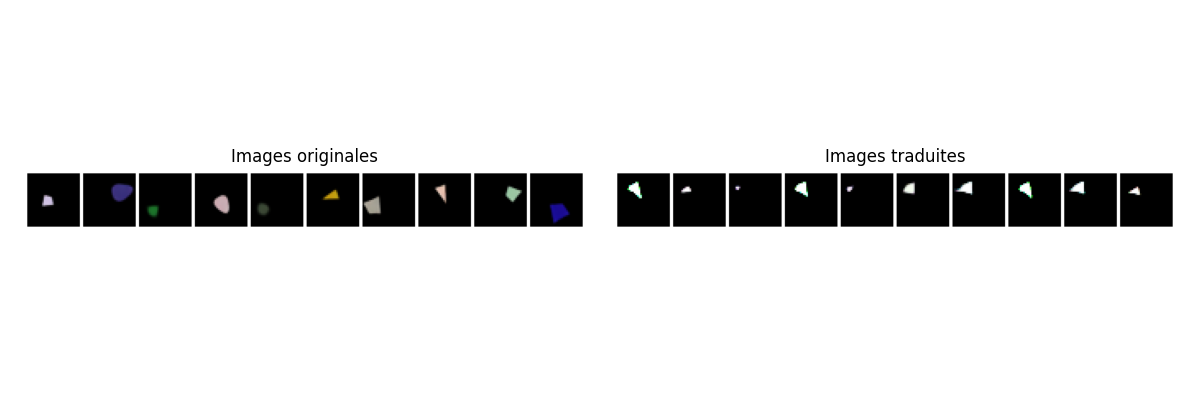

In [ ]:

fig = plot_original_translated_comparison(original_images_rgb, image_finale_rgb)
plt.show()



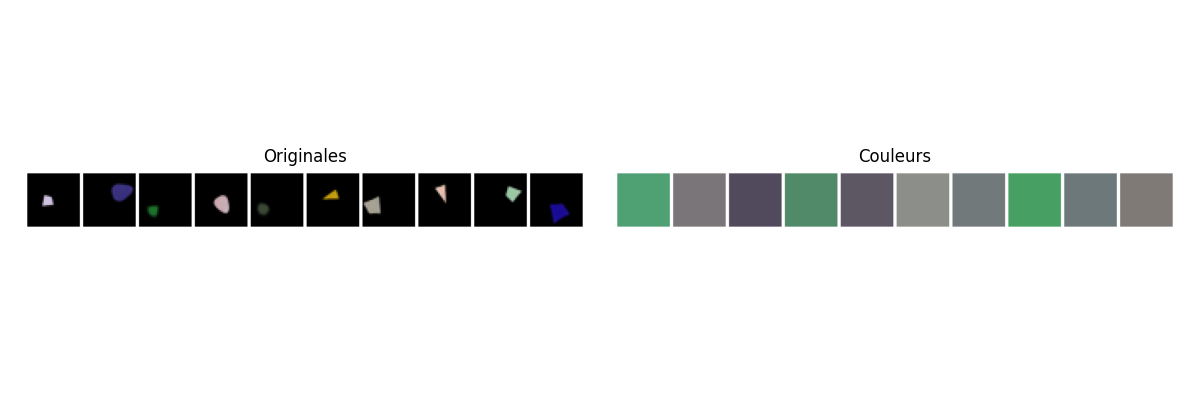

In [ ]:
colors_tensor =torch.from_numpy(colors_np).to('cuda')
colors_p = colors_tensor[:, [0, 1, 2]]

fig = plot_original_color_comparison(original_images_rgb, colors_p)
plt.show()


In [ ]:
del original_images_rgb
del image_finale_rgb
torch.cuda.empty_cache()